# EDA пользовательского поведения

В ноутбуке выполняется первичный анализ исторических данных пользователей:
проверяется структура датасета, распределения основных показателей и динамика активности.


In [ ]:
!pip install polars matplotlib seaborn -q

## Установка и импорт библиотек

Устанавливаем и импортируем библиотеки для работы с данными и визуализации.
Для обработки большого датасета используется Polars.

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive
import os

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


## Загрузка данных

Загружаем датасет `train.parquet` из Google Drive и смотрим базовую информацию:
размер, временной период и количество уникальных пользователей.

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/e-cup/data/train.parquet'
data = pl.read_parquet(file_path)

print(f"Rows: {data.shape[0]:,}, Columns: {data.shape[1]}")
print(f"Period: {data['event_date'].min()} to {data['event_date'].max()}")
print(f"Users: {data['user_id'].n_unique():,}")

Rows: 30,631,006, Columns: 18
Period: 2025-01-01 to 2026-02-13
Users: 250,000


### Первичный обзор структуры

Проверяем типы данных, наличие пропусков и смотрим на первые строки датасета,
чтобы понять формат записей.

In [ ]:
print("\nData types:")
print(data.dtypes)

print("\nNull counts:")
print(data.null_count())

print("\nFirst 5 rows:")
print(data.head(5))


Data types:
[Date, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Float64, Float64, Int64, Int64, Float64, Int64]

Null counts:
shape: (1, 18)
┌────────────┬─────────┬────────┬─────┬───┬─────────┬────────┬─────┬──────────┐
│ event_date ┆ user_id ┆ search ┆ cat ┆ … ┆ to_cart ┆ to_ord ┆ gmv ┆ searches │
│ ---        ┆ ---     ┆ ---    ┆ --- ┆   ┆ ---     ┆ ---    ┆ --- ┆ ---      │
│ u32        ┆ u32     ┆ u32    ┆ u32 ┆   ┆ u32     ┆ u32    ┆ u32 ┆ u32      │
╞════════════╪═════════╪════════╪═════╪═══╪═════════╪════════╪═════╪══════════╡
│ 0          ┆ 0       ┆ 0      ┆ 0   ┆ … ┆ 0       ┆ 0      ┆ 0   ┆ 0        │
└────────────┴─────────┴────────┴─────┴───┴─────────┴────────┴─────┴──────────┘

First 5 rows:
shape: (5, 18)
┌────────────┬─────────┬────────┬─────┬───┬─────────┬────────┬─────┬──────────┐
│ event_date ┆ user_id ┆ search ┆ cat ┆ … ┆ to_cart ┆ to_ord ┆ gmv ┆ searches │
│ ---        ┆ ---     ┆ ---    ┆ --- ┆   ┆ ---     ┆ ---    ┆ --- ┆ ---    

### Описание колонок датасета

| Колонка | Тип | Описание |
|---------|-----|----------|
| **event_date** | Date | Дата события. Период: с 2025-01-01 по 2026-02-13 |
| **user_id** | Int64 | Уникальный идентификатор пользователя |
| **search** | Int64 | Флаг использования Поиска в этот день (0 или 1) |
| **cat** | Int64 | Флаг использования Каталога в этот день (0 или 1) |
| **has_search_to_cart** | Int64 | Флаг: был ли добавлен товар в корзину после Поиска (0 или 1) |
| **has_search_to_ord** | Int64 | Флаг: была ли совершена покупка после Поиска (0 или 1) |
| **has_cat_to_cart** | Int64 | Флаг: был ли добавлен товар в корзину из Каталога (0 или 1) |
| **has_cat_to_ord** | Int64 | Флаг: была ли совершена покупка из Каталога (0 или 1) |
| **search_to_cart** | Int64 | Количество товаров, добавленных в корзину через Поиск |
| **search_to_ord** | Int64 | Количество товаров, купленных через Поиск |
| **cat_to_cart** | Int64 | Количество товаров, добавленных в корзину через Каталог |
| **cat_to_ord** | Int64 | Количество товаров, купленных через Каталог |
| **gmv_search** | Float64 | Суммарная стоимость заказов через Поиск |
| **gmv_cat** | Float64 | Суммарная стоимость заказов через Каталог |
| **to_cart** | Int64 | Общее количество добавлений в корзину (Поиск + Каталог) |
| **to_ord** | Int64 | Общее количество заказов (Поиск + Каталог) |
| **gmv** | Float64 | **Целевая переменная** — суммарный GMV за день |
| **searches** | Int64 | Общее количество поисковых запросов за день |

---

## Распределение числовых показателей

Рассчитываем базовую статистику для GMV, числа поисковых запросов,
добавлений в корзину и заказов.
Дополнительно оцениваем долю нулевых значений и влияние выбросов.

In [ ]:
numeric_cols = ['gmv', 'searches', 'to_cart', 'to_ord', 'gmv_search', 'gmv_cat']

stats = []
for col in numeric_cols:
    vals = data[col]
    stats.append({
        'Column': col,
        'Mean': f"{vals.mean():.2f}",
        'Median': f"{vals.median():.2f}",
        'Max': f"{vals.max():.2f}",
        'Zeros %': f"{(data.filter(pl.col(col)==0).shape[0]/data.shape[0]*100):.1f}%"
    })

print("\nStatistics:")
print(pl.DataFrame(stats))


Statistics:
shape: (6, 5)
┌────────────┬──────┬────────┬──────────┬─────────┐
│ Column     ┆ Mean ┆ Median ┆ Max      ┆ Zeros % │
│ ---        ┆ ---  ┆ ---    ┆ ---      ┆ ---     │
│ str        ┆ str  ┆ str    ┆ str      ┆ str     │
╞════════════╪══════╪════════╪══════════╪═════════╡
│ gmv        ┆ 8.88 ┆ 0.00   ┆ 73830.30 ┆ 84.5%   │
│ searches   ┆ 3.21 ┆ 2.00   ┆ 630.00   ┆ 19.3%   │
│ to_cart    ┆ 1.04 ┆ 0.00   ┆ 1535.00  ┆ 63.1%   │
│ to_ord     ┆ 0.26 ┆ 0.00   ┆ 138.00   ┆ 84.5%   │
│ gmv_search ┆ 8.23 ┆ 0.00   ┆ 73830.30 ┆ 85.3%   │
│ gmv_cat    ┆ 0.65 ┆ 0.00   ┆ 18838.68 ┆ 98.9%   │
└────────────┴──────┴────────┴──────────┴─────────┘


## Визуализация распределений

Строим гистограммы ненулевых значений основных числовых признаков.
Логарифмическая шкала по оси Y используется из-за сильной асимметрии распределений.

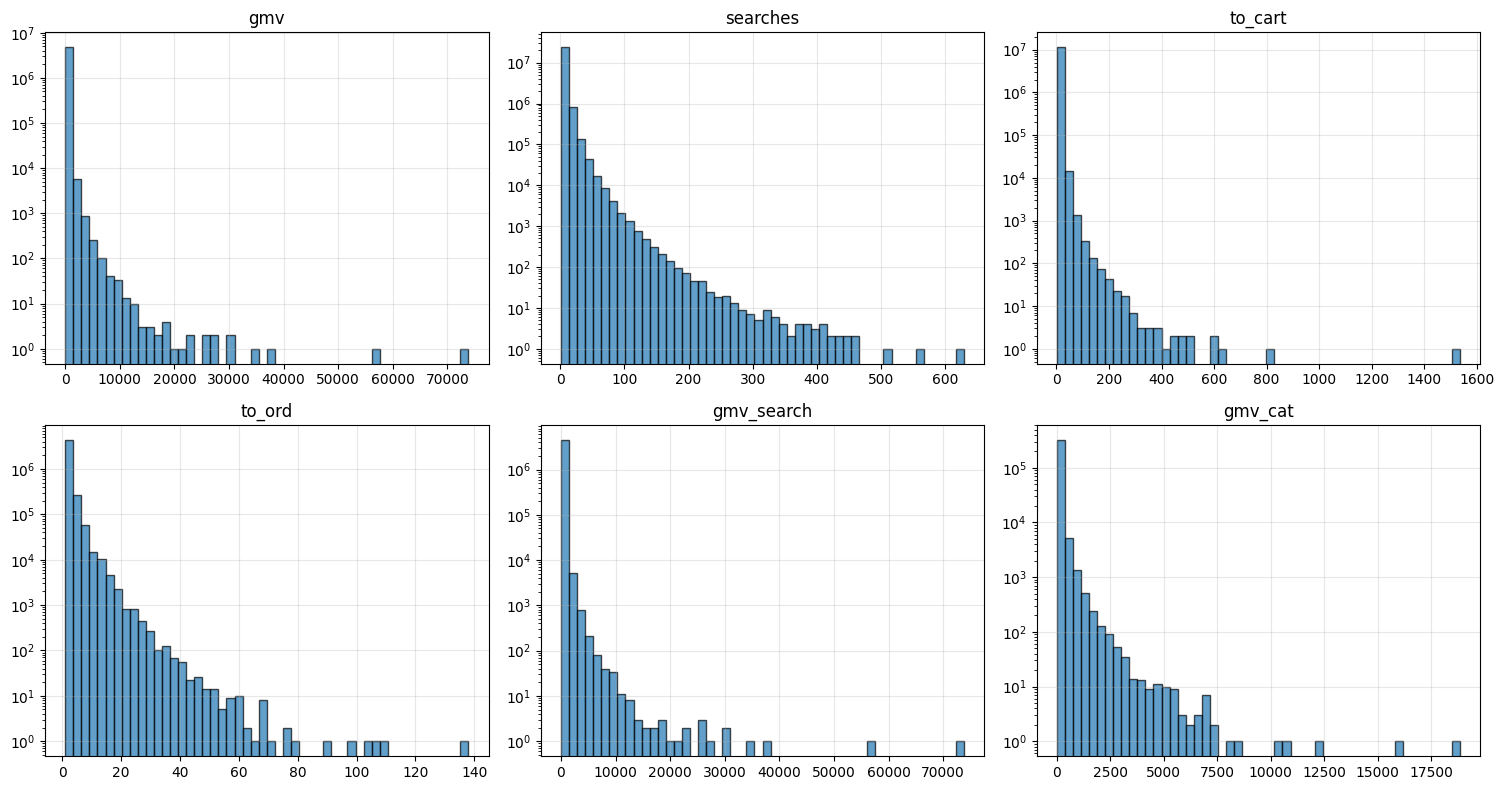

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    non_zero = data.filter(pl.col(col) > 0)[col].to_list()
    axes[i].hist(non_zero, bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_yscale('log')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Дневная динамика активности

Агрегируем данные по датам и рассчитываем количество активных пользователей,
общий GMV, поисковые запросы, добавления в корзину и заказы.

In [ ]:
daily = data.group_by('event_date').agg([
    pl.col('user_id').n_unique().alias('users'),
    pl.sum('gmv').alias('gmv'),
    pl.sum('searches').alias('searches'),
    pl.sum('to_cart').alias('cart'),
    pl.sum('to_ord').alias('orders')
]).sort('event_date')

print("\nFirst 5 days:")
print(daily.head(5))

print("\nLast 5 days:")
print(daily.tail(5))


First 5 days:
shape: (5, 6)
┌────────────┬───────┬───────────────┬──────────┬───────┬────────┐
│ event_date ┆ users ┆ gmv           ┆ searches ┆ cart  ┆ orders │
│ ---        ┆ ---   ┆ ---           ┆ ---      ┆ ---   ┆ ---    │
│ date       ┆ u32   ┆ f64           ┆ i64      ┆ i64   ┆ i64    │
╞════════════╪═══════╪═══════════════╪══════════╪═══════╪════════╡
│ 2025-01-01 ┆ 43516 ┆ 374066.469016 ┆ 136443   ┆ 38548 ┆ 8827   │
│ 2025-01-02 ┆ 52556 ┆ 489227.996022 ┆ 174063   ┆ 51779 ┆ 12381  │
│ 2025-01-03 ┆ 53609 ┆ 473332.477438 ┆ 175456   ┆ 51388 ┆ 12340  │
│ 2025-01-04 ┆ 54882 ┆ 450219.389198 ┆ 182234   ┆ 54055 ┆ 12785  │
│ 2025-01-05 ┆ 55531 ┆ 465926.986665 ┆ 184256   ┆ 54809 ┆ 12893  │
└────────────┴───────┴───────────────┴──────────┴───────┴────────┘

Last 5 days:
shape: (5, 6)
┌────────────┬───────┬───────────────┬──────────┬────────┬────────┐
│ event_date ┆ users ┆ gmv           ┆ searches ┆ cart   ┆ orders │
│ ---        ┆ ---   ┆ ---           ┆ ---      ┆ ---    ┆ ---    │
│ 

## Графики временной динамики

Визуализируем изменение пользовательской активности и денежных показателей
на протяжении всего исторического периода.

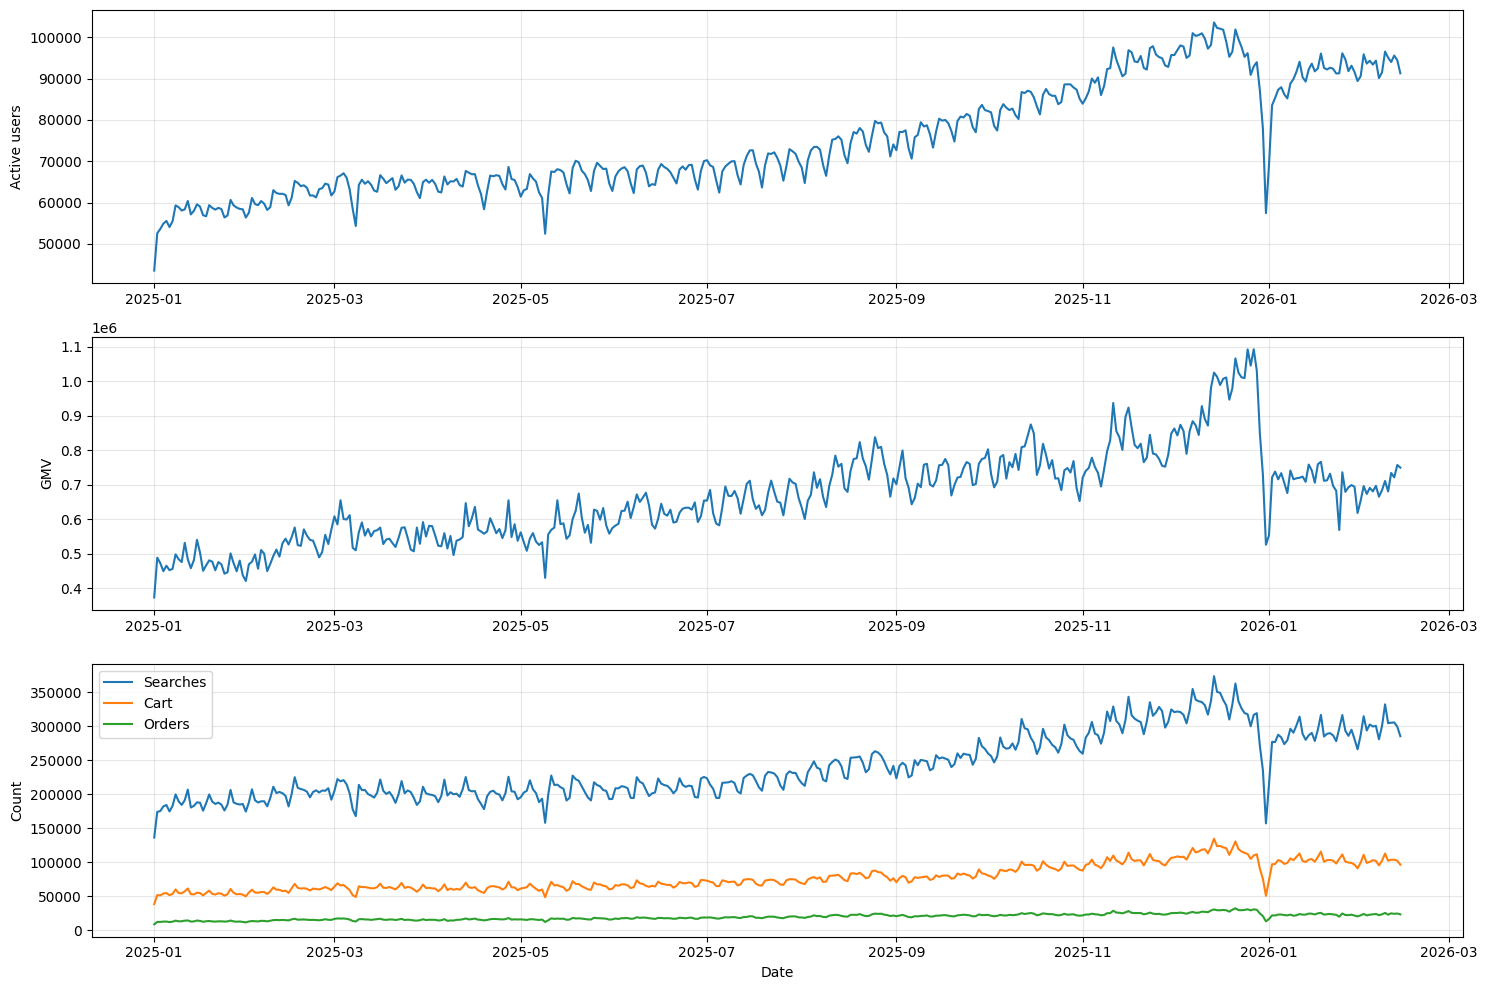

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

axes[0].plot(daily['event_date'], daily['users'])
axes[0].set_ylabel('Active users')
axes[0].grid(True, alpha=0.3)

axes[1].plot(daily['event_date'], daily['gmv'])
axes[1].set_ylabel('GMV')
axes[1].grid(True, alpha=0.3)

axes[2].plot(daily['event_date'], daily['searches'], label='Searches')
axes[2].plot(daily['event_date'], daily['cart'], label='Cart')
axes[2].plot(daily['event_date'], daily['orders'], label='Orders')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Count')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Проверка консистентности данных

Убеждаемся, что целевая переменная `gmv` действительно равна сумме
`gmv_search + gmv_cat` во всех строках.

In [ ]:
check = data.with_columns(
    ((pl.col('gmv') - (pl.col('gmv_search') + pl.col('gmv_cat'))).abs() < 0.001).alias('is_equal')
)

print(f"Строк где gmv = gmv_search + gmv_cat: {check.filter(pl.col('is_equal')).shape[0]:,} из {check.shape[0]:,}")

Строк где gmv = gmv_search + gmv_cat: 30,631,006 из 30,631,006


## Пользовательские агрегаты

Рассчитываем статистику на уровне пользователя:

- количество активных дней;
- суммарный GMV;
- суммарное количество заказов.

In [ ]:
user_stats = data.group_by('user_id').agg([
    pl.len().alias('active_days'),
    pl.sum('gmv').alias('total_gmv'),
    pl.sum('to_ord').alias('total_orders')
])

print(f"\nTotal users: {user_stats.shape[0]:,}")
print(f"\nActive days:")
print(f"  Min: {user_stats['active_days'].min()}")
print(f"  Max: {user_stats['active_days'].max()}")
print(f"  Mean: {user_stats['active_days'].mean():.2f}")

print(f"\nTotal GMV:")
print(f"  Min: {user_stats['total_gmv'].min():.2f}")
print(f"  Max: {user_stats['total_gmv'].max():.2f}")
print(f"  Mean: {user_stats['total_gmv'].mean():.2f}")

zero_gmv = user_stats.filter(pl.col('total_gmv') == 0).shape[0]
print(f"\nUsers with zero GMV: {zero_gmv:,} ({zero_gmv/user_stats.shape[0]*100:.1f}%)")


Total users: 250,000

Active days:
  Min: 3
  Max: 409
  Mean: 122.52

Total GMV:
  Min: 0.00
  Max: 123075.70
  Mean: 1088.41

Users with zero GMV: 30,832 (12.3%)


## Корреляционная матрица — описание метрик

| Метрика | Что показывает | В чем измеряется |
|---------|----------------|------------------|
| **gmv** | Общая стоимость всех заказов за день | Рубли (деньги) |
| **searches** | Количество поисковых запросов за день | Штуки (количество) |
| **to_cart** | Количество добавлений товаров в корзину за день | Штуки (количество товаров) |
| **to_ord** | Количество заказов за день | Штуки (количество заказов) |
| **search_to_cart** | Количество добавлений в корзину через поиск | Штуки (количество товаров) |
| **cat_to_cart** | Количество добавлений в корзину через каталог | Штуки (количество товаров) |

---

## Распределение активности пользователей

Изучаем связь между количеством активных дней, заказами и суммарным GMV.
Это позволяет выделить пользователей с высокой и низкой активностью.

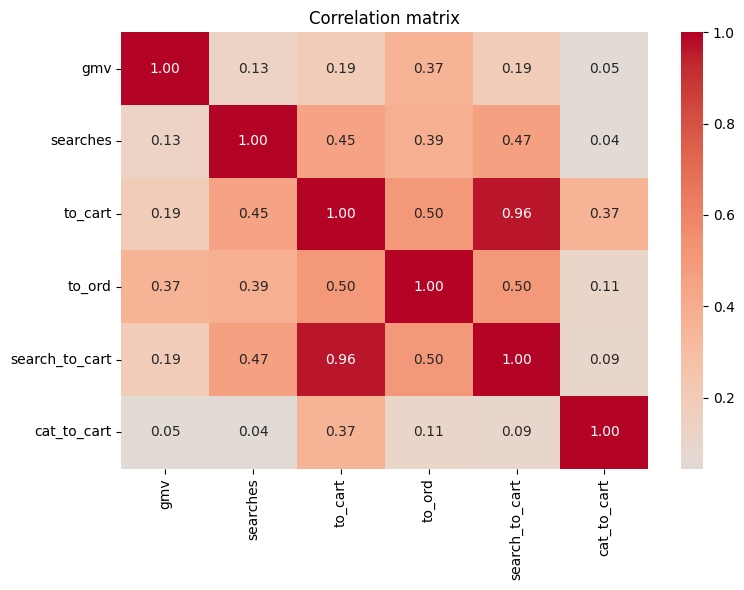

In [ ]:
corr_cols = ['gmv', 'searches', 'to_cart', 'to_ord', 'search_to_cart', 'cat_to_cart']
corr_matrix = data.select(corr_cols).to_pandas().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

### Результаты корреляционного анализа

**to_ord (0.37)** — сильнее всего связан с GMV.  
**to_cart и search_to_cart (0.96)** — почти дублируют друг друга.  
**search_to_cart (0.47 с searches, 0.50 с to_ord)** — поиск ведет в корзину и заказы.  
**cat_to_cart (0.05 с gmv, 0.04 с searches)** — каталог изолирован, почти не влияет.  
**searches (0.13 с gmv)** — поиск слабо связан с выручкой.

**Главное:**  
- Лучший предиктор GMV → **to_ord**  
- Можно удалить одну из дублирующих метрик → **to_cart** или **search_to_cart**  
- Каталог (cat_to_cart) можно исключить — он почти не влияет  
- Основной канал продаж — **поиск**

## Выбросы

Оцениваем количество выбросов в основных числовых признаках с помощью правила IQR.
Результаты используются для понимания масштаба длинных хвостов распределений.

In [ ]:
def show_outliers(col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 3 * iqr
    outliers = data.filter(pl.col(col) > upper).shape[0]
    print(f"{col:15} | upper: {upper:.2f} | outliers: {outliers:,} ({outliers/data.shape[0]*100:.3f}%)")

print("\nOutliers (IQR method, 3x):")
print("-" * 60)
for col in ['gmv', 'searches', 'to_cart', 'to_ord']:
    show_outliers(col)


Outliers (IQR method, 3x):
------------------------------------------------------------
gmv             | upper: 0.00 | outliers: 4,736,907 (15.464%)
searches        | upper: 13.00 | outliers: 1,034,281 (3.377%)
to_cart         | upper: 4.00 | outliers: 1,765,822 (5.765%)
to_ord          | upper: 0.00 | outliers: 4,736,907 (15.464%)


In [ ]:
print("САМЫЕ КРУПНЫЕ ПОКУПАТЕЛИ")
print("=" * 60)

top_buyers = user_stats.sort('total_gmv', descending=True).head(10)
print(top_buyers)

print("\nТОП-10 ПО АКТИВНОСТИ (дни)")
print("=" * 60)
top_active = user_stats.sort('active_days', descending=True).head(10)
print(top_active)

САМЫЕ КРУПНЫЕ ПОКУПАТЕЛИ
shape: (10, 4)
┌─────────┬─────────────┬───────────────┬──────────────┐
│ user_id ┆ active_days ┆ total_gmv     ┆ total_orders │
│ ---     ┆ ---         ┆ ---           ┆ ---          │
│ i64     ┆ u32         ┆ f64           ┆ i64          │
╞═════════╪═════════════╪═══════════════╪══════════════╡
│ 466880  ┆ 390         ┆ 123075.702541 ┆ 362          │
│ 168367  ┆ 206         ┆ 114351.693363 ┆ 711          │
│ 621247  ┆ 248         ┆ 110065.374038 ┆ 211          │
│ 204668  ┆ 349         ┆ 98573.800105  ┆ 373          │
│ 747516  ┆ 102         ┆ 98419.946134  ┆ 40           │
│ 642061  ┆ 79          ┆ 95634.144357  ┆ 31           │
│ 583330  ┆ 211         ┆ 94102.55783   ┆ 140          │
│ 736782  ┆ 135         ┆ 89989.668918  ┆ 59           │
│ 715109  ┆ 128         ┆ 87091.142158  ┆ 31           │
│ 158093  ┆ 355         ┆ 83523.941904  ┆ 161          │
└─────────┴─────────────┴───────────────┴──────────────┘

ТОП-10 ПО АКТИВНОСТИ (дни)
shape: (10, 4)
┌────

In [ ]:
print("ПОЛЬЗОВАТЕЛИ БЕЗ ПОКУПОК")
print("=" * 60)

zero_buyers = user_stats.filter(pl.col('total_gmv') == 0)

print(f"Всего пользователей без покупок: {zero_buyers.shape[0]:,}")
print(f"Доля от всех пользователей: {zero_buyers.shape[0] / user_stats.shape[0] * 100:.1f}%")

print("\nСтатистика по активности (дни):")
print(f"  Мин: {zero_buyers['active_days'].min()}")
print(f"  Макс: {zero_buyers['active_days'].max()}")
print(f"  Сред: {zero_buyers['active_days'].mean():.2f}")

print("\nТОП-10 САМЫХ АКТИВНЫХ ИЗ НЕПОКУПАЮЩИХ:")
print("-" * 60)
top_zero_active = zero_buyers.sort('active_days', descending=True).head(10)
print(top_zero_active)

ПОЛЬЗОВАТЕЛИ БЕЗ ПОКУПОК
Всего пользователей без покупок: 30,832
Доля от всех пользователей: 12.3%

Статистика по активности (дни):
  Мин: 3
  Макс: 391
  Сред: 44.39

ТОП-10 САМЫХ АКТИВНЫХ ИЗ НЕПОКУПАЮЩИХ:
------------------------------------------------------------
shape: (10, 4)
┌─────────┬─────────────┬───────────┬──────────────┐
│ user_id ┆ active_days ┆ total_gmv ┆ total_orders │
│ ---     ┆ ---         ┆ ---       ┆ ---          │
│ i64     ┆ u32         ┆ f64       ┆ i64          │
╞═════════╪═════════════╪═══════════╪══════════════╡
│ 567980  ┆ 391         ┆ 0.0       ┆ 0            │
│ 523675  ┆ 389         ┆ 0.0       ┆ 0            │
│ 11114   ┆ 389         ┆ 0.0       ┆ 0            │
│ 853534  ┆ 377         ┆ 0.0       ┆ 0            │
│ 583425  ┆ 374         ┆ 0.0       ┆ 0            │
│ 111428  ┆ 372         ┆ 0.0       ┆ 0            │
│ 513903  ┆ 364         ┆ 0.0       ┆ 0            │
│ 670324  ┆ 360         ┆ 0.0       ┆ 0            │
│ 47724   ┆ 358         ┆ 0.

### Список пользователей без покупок

**Что делаем:**  
Сохраняем `user_id` всех пользователей, у которых `total_gmv = 0`, в отдельный список.

**Зачем:**  
Чтобы после обучения модели **проверить**, как она предсказала этих пользователей. Если модель предсказала им высокий GMV — значит, она что-то не поняла в данных.

**Где пригодится:**  
При анализе результатов — сравним предсказанные значения с реальными (которые = 0) и увидим, насколько модель ошибается на этой группе.

In [ ]:
zero_buyer_ids = zero_buyers['user_id'].to_list()

### Анализ повторных покупок и интервалов между ними

---

**1. Повторные покупки**

Из 219,168 пользователей, совершивших хотя бы одну покупку:

- **6.1%** (13,284) купили только один раз
- **93.9%** (205,884) совершили повторные покупки
- **63.4%** (138,933) сделали более 10 заказов

**Вывод:** большинство пользователей возвращаются за новыми покупками. Платформа хорошо удерживает клиентов.

---

**2. Интервал между покупками**

- **Средний интервал:** 13 дней
- **Медианный интервал:** 5 дней
- **Минимальный:** 1 день
- **Максимальный:** 405 дней

**Распределение интервалов:**

| Интервал | Доля |
|----------|------|
| 0–7 дней | 60.3% |
| 8–14 дней | 16.4% |
| 15–30 дней | 13.2% |
| 31–60 дней | 6.5% |
| 61+ дней | 3.7% |

**Вывод:** большинство покупок (60%) происходят с интервалом до недели. Это говорит о том, что пользователи покупают часто и регулярно. Модель должна учитывать эту частоту — например, через признаки среднего интервала между покупками для каждого пользователя.

In [ ]:
# ============================================================
# BLOCK: Repeat purchases
# ============================================================

print("REPEAT PURCHASES")
print("=" * 60)

buyers = user_stats.filter(pl.col('total_orders') > 0)
total_buyers = buyers.shape[0]

print(f"Total buyers: {total_buyers:,}")
print(f"  One-time: {buyers.filter(pl.col('total_orders') == 1).shape[0]:,} ({buyers.filter(pl.col('total_orders') == 1).shape[0] / total_buyers * 100:.1f}%)")
print(f"  Repeat (>1): {buyers.filter(pl.col('total_orders') > 1).shape[0]:,} ({buyers.filter(pl.col('total_orders') > 1).shape[0] / total_buyers * 100:.1f}%)")
print(f"  Frequent (>10): {buyers.filter(pl.col('total_orders') > 10).shape[0]:,}")

order_counts = buyers.group_by('total_orders').agg([
    pl.len().alias('users')
]).sort('total_orders')

print("\nDistribution by order count (top 10):")
print(order_counts.head(10))


# ============================================================
# BLOCK: Time between purchases
# ============================================================

print("\nTIME BETWEEN PURCHASES")
print("=" * 60)

orders_data = data.filter(pl.col('to_ord') > 0).select(['user_id', 'event_date', 'to_ord'])
orders_data = orders_data.sort(['user_id', 'event_date'])

orders_data = orders_data.with_columns(
    pl.col('event_date').shift(1).over('user_id').alias('prev_date')
)

orders_data = orders_data.with_columns(
    (pl.col('event_date') - pl.col('prev_date')).dt.total_days().alias('days_between')
)

intervals = orders_data.filter(pl.col('days_between').is_not_null())

print(f"Total intervals: {intervals.shape[0]:,}")
print(f"  Min: {intervals['days_between'].min()} days")
print(f"  Max: {intervals['days_between'].max()} days")
print(f"  Mean: {intervals['days_between'].mean():.1f} days")
print(f"  Median: {intervals['days_between'].median():.1f} days")

print("\nInterval distribution:")
bins = [0, 1, 3, 7, 14, 30, 60, 90, 180, 365]
labels = ['0-1d', '2-3d', '4-7d', '8-14d', '15-30d', '31-60d', '61-90d', '91-180d', '181-365d']

intervals_with_groups = intervals.with_columns(
    pl.when(pl.col('days_between') <= 1).then(0)
    .when(pl.col('days_between') <= 3).then(1)
    .when(pl.col('days_between') <= 7).then(2)
    .when(pl.col('days_between') <= 14).then(3)
    .when(pl.col('days_between') <= 30).then(4)
    .when(pl.col('days_between') <= 60).then(5)
    .when(pl.col('days_between') <= 90).then(6)
    .when(pl.col('days_between') <= 180).then(7)
    .otherwise(8)
    .alias('interval_group')
)

for i, label in enumerate(labels):
    count = intervals_with_groups.filter(pl.col('interval_group') == i).shape[0]
    pct = count / intervals.shape[0] * 100
    print(f"  {label:10} -> {count:6,} ({pct:5.1f}%)")

REPEAT PURCHASES
Total buyers: 219,168
  One-time: 13,284 (6.1%)
  Repeat (>1): 205,884 (93.9%)
  Frequent (>10): 138,933

Distribution by order count (top 10):
shape: (10, 2)
┌──────────────┬───────┐
│ total_orders ┆ users │
│ ---          ┆ ---   │
│ i64          ┆ u32   │
╞══════════════╪═══════╡
│ 1            ┆ 13284 │
│ 2            ┆ 11018 │
│ 3            ┆ 9335  │
│ 4            ┆ 8710  │
│ 5            ┆ 7535  │
│ 6            ┆ 6844  │
│ 7            ┆ 6509  │
│ 8            ┆ 5947  │
│ 9            ┆ 5744  │
│ 10           ┆ 5309  │
└──────────────┴───────┘

TIME BETWEEN PURCHASES
Total intervals: 4,517,739
  Min: 1 days
  Max: 405 days
  Mean: 13.0 days
  Median: 5.0 days

Interval distribution:
  0-1d       -> 820,678 ( 18.2%)
  2-3d       -> 930,219 ( 20.6%)
  4-7d       -> 969,511 ( 21.5%)
  8-14d      -> 739,682 ( 16.4%)
  15-30d     -> 597,195 ( 13.2%)
  31-60d     -> 292,403 (  6.5%)
  61-90d     -> 85,924 (  1.9%)
  91-180d    -> 66,414 (  1.5%)
  181-365d   -> 15,7

### Анализ нелинейных зависимостей

---

**1. Зависимость: поиски → вероятность покупки**

| Поисков в день | Дней | Заказов | Заказов/день |
|----------------|------|---------|--------------|
| 0 | 5,924,631 | 117,344 | 0.0198 |
| 1 | 8,219,266 | 988,936 | 0.1203 |
| 2 | 4,899,555 | 918,962 | 0.1876 |
| 3-4 | 5,193,079 | 1,473,897 | 0.2838 |
| 5-9 | 4,330,475 | 2,097,170 | 0.4843 |
| 10-19 | 1,609,961 | 1,455,287 | 0.9039 |
| 20-49 | 414,926 | 798,435 | 1.9243 |
| 50-99 | 35,178 | 171,023 | 4.8616 |
| 100+ | 3,935 | 30,914 | 7.8562 |

**Вывод:** чем больше поисков, тем выше вероятность покупки. Зависимость нелинейная — при 0 поисков почти нет заказов, а при 100+ поисков в день каждый день приносит почти 8 заказов. **Пороговый эффект:** после 5 поисков заказов становится заметно больше.

---

**2. Зависимость: корзина → вероятность покупки**

| Добавлений в корзину | Дней | Заказов | Заказов/день |
|----------------------|------|---------|--------------|
| 0 | 19,316,155 | 0 | 0.0000 |
| 1 | 5,053,025 | 1,845,422 | 0.3652 |
| 2 | 2,422,901 | 1,395,980 | 0.5762 |
| 3-4 | 2,073,103 | 1,746,909 | 0.8427 |
| 5-9 | 1,333,499 | 1,846,021 | 1.3843 |
| 10-19 | 363,652 | 924,593 | 2.5425 |
| 20-49 | 64,741 | 276,249 | 4.2670 |
| 50+ | 3,930 | 16,794 | 4.2733 |

**Вывод:** без добавлений в корзину заказов нет. Каждое добавление увеличивает вероятность покупки. После 20+ добавлений заказов становится значительно больше. **Пороговый эффект:** 1 добавление в корзину уже дает 0.36 заказа в день.

---

**3. Зависимость: дни активности → GMV**

| Активных дней | Пользователей | Средний GMV | Средних заказов |
|---------------|---------------|-------------|-----------------|
| 0-9 | 3,691 | 26.50 | 0.59 |
| 10-29 | 26,521 | 96.13 | 2.20 |
| 30-59 | 44,619 | 251.54 | 6.44 |
| 60-99 | 47,990 | 545.25 | 14.55 |
| 100-199 | 77,399 | 1,189.96 | 34.05 |
| 200-299 | 38,226 | 2,365.07 | 72.06 |
| 300-399 | 11,459 | 4,250.03 | 138.31 |
| 400+ | 95 | 8,995.87 | 326.56 |

**Вывод:** чем больше дней активности, тем выше и GMV, и число заказов. Зависимость экспоненциальная — пользователи с 400+ днями активности тратят в среднем ~9,000 руб. за весь период.

---

### Общий вывод по нелинейным зависимостям

| Зависимость | Характер | Пороговый эффект |
|-------------|----------|------------------|
| Поиски → покупки | Растет с каждым поиском | После 5 поисков |
| Корзина → покупки | Резкий рост от 0 к 1 | 1 добавление в корзину |
| Активные дни → GMV | Экспоненциальный рост | После 100 дней |

**Для модели:** эти зависимости нужно учитывать. Признаки должны отражать нелинейность — можно использовать логарифмирование или бинаризацию.

In [ ]:
# ============================================================
# BLOCK: Non-linear relationships (searches -> purchases)
# ============================================================

print("\nSEARCHES -> PURCHASE PROBABILITY")
print("=" * 60)

search_bins = [0, 1, 2, 3, 5, 10, 20, 50, 100]
search_labels = ['0', '1', '2', '3-4', '5-9', '10-19', '20-49', '50-99', '100+']

data_with_search_bins = data.with_columns(
    pl.when(pl.col('searches') <= 0).then(0)
    .when(pl.col('searches') <= 1).then(1)
    .when(pl.col('searches') <= 2).then(2)
    .when(pl.col('searches') <= 4).then(3)
    .when(pl.col('searches') <= 9).then(4)
    .when(pl.col('searches') <= 19).then(5)
    .when(pl.col('searches') <= 49).then(6)
    .when(pl.col('searches') <= 99).then(7)
    .otherwise(8)
    .alias('search_group')
)

search_conversion = data_with_search_bins.group_by('search_group').agg([
    pl.len().alias('total_days'),
    pl.col('to_ord').sum().alias('total_orders'),
    (pl.col('to_ord').sum() / pl.len()).alias('orders_per_day')
]).sort('search_group')

print("Search group | Days | Orders | Orders/day")
print("-" * 50)
for i, label in enumerate(search_labels):
    row = search_conversion.filter(pl.col('search_group') == i)
    if row.shape[0] > 0:
        print(f"{label:11} | {row['total_days'].to_list()[0]:6,} | {row['total_orders'].to_list()[0]:7,} | {row['orders_per_day'].to_list()[0]:.4f}")


# ============================================================
# BLOCK: Non-linear relationships (cart -> purchases)
# ============================================================

print("\nCART -> PURCHASE PROBABILITY")
print("=" * 60)

cart_bins = [0, 1, 2, 3, 5, 10, 20, 50]
cart_labels = ['0', '1', '2', '3-4', '5-9', '10-19', '20-49', '50+']

data_with_cart_bins = data.with_columns(
    pl.when(pl.col('to_cart') <= 0).then(0)
    .when(pl.col('to_cart') <= 1).then(1)
    .when(pl.col('to_cart') <= 2).then(2)
    .when(pl.col('to_cart') <= 4).then(3)
    .when(pl.col('to_cart') <= 9).then(4)
    .when(pl.col('to_cart') <= 19).then(5)
    .when(pl.col('to_cart') <= 49).then(6)
    .otherwise(7)
    .alias('cart_group')
)

cart_conversion = data_with_cart_bins.group_by('cart_group').agg([
    pl.len().alias('total_days'),
    pl.col('to_ord').sum().alias('total_orders'),
    (pl.col('to_ord').sum() / pl.len()).alias('orders_per_day')
]).sort('cart_group')

print("Cart group | Days | Orders | Orders/day")
print("-" * 50)
for i, label in enumerate(cart_labels):
    row = cart_conversion.filter(pl.col('cart_group') == i)
    if row.shape[0] > 0:
        print(f"{label:9} | {row['total_days'].to_list()[0]:6,} | {row['total_orders'].to_list()[0]:7,} | {row['orders_per_day'].to_list()[0]:.4f}")


# ============================================================
# BLOCK: Non-linear relationships (active days -> GMV)
# ============================================================

print("\nACTIVE DAYS -> GMV")
print("=" * 60)

active_bins = [0, 10, 30, 60, 100, 200, 300, 400]
active_labels = ['0-9d', '10-29d', '30-59d', '60-99d', '100-199d', '200-299d', '300-399d', '400+']

user_stats_with_bins = user_stats.with_columns(
    pl.when(pl.col('active_days') <= 9).then(0)
    .when(pl.col('active_days') <= 29).then(1)
    .when(pl.col('active_days') <= 59).then(2)
    .when(pl.col('active_days') <= 99).then(3)
    .when(pl.col('active_days') <= 199).then(4)
    .when(pl.col('active_days') <= 299).then(5)
    .when(pl.col('active_days') <= 399).then(6)
    .otherwise(7)
    .alias('active_group')
)

active_stats = user_stats_with_bins.group_by('active_group').agg([
    pl.len().alias('users'),
    pl.col('total_gmv').mean().alias('avg_gmv'),
    pl.col('total_orders').mean().alias('avg_orders')
]).sort('active_group')

print("Active group | Users | Avg GMV | Avg Orders")
print("-" * 60)
for i, label in enumerate(active_labels):
    row = active_stats.filter(pl.col('active_group') == i)
    if row.shape[0] > 0:
        print(f"{label:13} | {row['users'].to_list()[0]:6,} | {row['avg_gmv'].to_list()[0]:10.2f} | {row['avg_orders'].to_list()[0]:12.2f}")


SEARCHES -> PURCHASE PROBABILITY
Search group | Days | Orders | Orders/day
--------------------------------------------------
0           | 5,924,631 | 117,344 | 0.0198
1           | 8,219,266 | 988,936 | 0.1203
2           | 4,899,555 | 918,962 | 0.1876
3-4         | 5,193,079 | 1,473,897 | 0.2838
5-9         | 4,330,475 | 2,097,170 | 0.4843
10-19       | 1,609,961 | 1,455,287 | 0.9039
20-49       | 414,926 | 798,435 | 1.9243
50-99       | 35,178 | 171,023 | 4.8616
100+        |  3,935 |  30,914 | 7.8562

CART -> PURCHASE PROBABILITY
Cart group | Days | Orders | Orders/day
--------------------------------------------------
0         | 19,316,155 |       0 | 0.0000
1         | 5,053,025 | 1,845,422 | 0.3652
2         | 2,422,901 | 1,395,980 | 0.5762
3-4       | 2,073,103 | 1,746,909 | 0.8427
5-9       | 1,333,499 | 1,846,021 | 1.3843
10-19     | 363,652 | 924,593 | 2.5425
20-49     | 64,741 | 276,249 | 4.2670
50+       |  3,930 |  16,794 | 4.2733

ACTIVE DAYS -> GMV
Active group | Use

## Итоги исследовательского анализа

На этом этапе зафиксированы основные свойства данных:

- датасет разреженный;
- GMV имеет большое количество нулей;
- распределения основных показателей имеют длинный правый хвост;
- небольшая доля пользователей формирует значительную часть GMV;
- наличие активности не всегда приводит к покупке.

Эти особенности необходимо учитывать при дальнейшем формировании признаков и обучении модели.